In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt

In [7]:
#1. Load dataset
X, y = load_breast_cancer(return_X_y=True)

In [8]:
# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


In [13]:
# 3. Build boosting model (AdaBoost with weak learner)
base_model = DecisionTreeClassifier(max_depth=1,random_state=42)
boost_model = AdaBoostClassifier(
    estimator=base_model, 
    n_estimators=50, 
    learning_rate=1.0, random_state=42
)

In [14]:
#4. Train the model
boost_model.fit(X_train, y_train)  

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

In [21]:
# 5. Predictions
y_pred = boost_model.predict(X_test)
y_prob = boost_model.predict_proba(X_test)[:, 1]

In [22]:
# 6. Evaluation
print("AdaBoost evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

AdaBoost evaluation:
Accuracy: 0.9649
Precision: 0.9589
Recall: 0.9859
F1 Score: 0.9722
ROC AUC Score: 0.9925
Confusion Matrix:
 [[40  3]
 [ 1 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [23]:
#7 cross-validation
cv_scores = cross_val_score(boost_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross-validation scores: [0.95614035 0.95614035 0.99122807 0.96491228 0.97345133]
Mean CV Score: 0.9683744760130415


In [24]:
#8 compare with single week learner
single_model = DecisionTreeClassifier(max_depth=1, random_state=42)
single_model.fit(X_train, y_train)
single_pred = single_model.predict(X_test) 
print("Single Model Accuracy:", accuracy_score(y_test, single_pred))
print("Boosting Model Accuracy:", accuracy_score(y_test, y_pred))

Single Model Accuracy: 0.8947368421052632
Boosting Model Accuracy: 0.9649122807017544


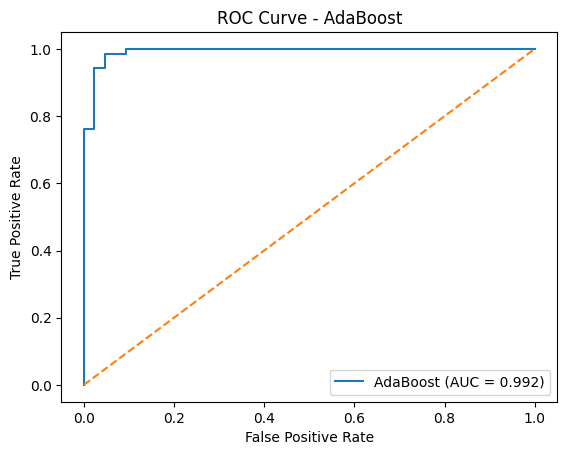

In [25]:
#9 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'AdaBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost')
plt.legend()
plt.show()